# OLMo-2-1B × opc-sft-stage2 leaderboard — long-horizon (r=64, 9000 steps, ~225M tokens)

Long-horizon characterization from `docs/notes/polar_product/tight_chord_paper_plan.md` (Phase L). Cell: OLMo-2-1B × `opc-sft-stage2` (4 sub-configs concat, 436k docs → 150k packed slots @ seq=2048) × r=64 × global_batch=16 (batch=4 × accum=4) × packed_v1 × constant LR × α=r × all-linear × bf16 × compile × single-GPU Blackwell. `max_steps=9000` ≈ 225M unique content tokens (~295M slot-tokens at 75% fill).

Phase L LR sweep, seed=0, two optimizers. The grid pools three sub-sweeps per optimizer (original L1, packed-v1.1 repack of the same η values, and an extension to higher η). All groups in this notebook are treated as one pool — `packed_v1` and `packed_v1.1` are not distinguished here.

- **AdamW**: η ∈ {3e-5, 1e-4, 3e-4, 1e-3, 3e-3}
- **chord-tight** (`adam-polar-product-lora-coupled-spectral-chord-tight`, k=1): η ∈ {3e-3, 1e-2, 3e-2, 1e-1, 3e-1}

Source log groups: `{adamw,chord_tight}_phase_L_lrsweep_r64_{blackwell,repack_blackwell,extension_blackwell}` (6 groups total).

**σ anchor**: no Phase L multi-seed run yet. σ_AdamW(packed_v1, r=64, **4k horizon**) = 0.0017 is the only available number, used here as a *proxy* for unit conversion only. A 9000-step multi-seed AdamW run is needed before σ-units transfer to writeups.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.loader import load_runs
from lora_playground.plot_utils import standard_sweep_figure

GROUPS = [
    'adamw_phase_L_lrsweep_r64_blackwell',
    'chord_tight_phase_L_lrsweep_r64_blackwell',
    'adamw_phase_L_lrsweep_r64_repack_blackwell',
    'chord_tight_phase_L_lrsweep_r64_repack_blackwell',
    'adamw_phase_L_lrsweep_r64_extension_blackwell',
    'chord_tight_phase_L_lrsweep_r64_extension_blackwell',
]

runs = load_runs(where={'log_group': GROUPS},
                 logs_root='../logs', warn_cross_commit=False)

# Dedup: keep the longest-trajectory run per (optimizer, lr).
# Phase-L extension runs were resumed from checkpoints, producing two cfg
# events per cell that differ in `resume_from`/`checkpoint_dir`. The loader
# treats them as distinct series; for the leaderboard we want the single
# continuation that reaches the highest step.
_dedup = {}
for cfg, evs in runs:
    key = (cfg['optimizer'], float(cfg['lr']))
    last_step = evs[-1]['step'] if evs else -1
    prev = _dedup.get(key)
    if prev is None or last_step > prev[1]['step']:
        _dedup[key] = (cfg, evs[-1] if evs else None, evs, last_step)
runs = [(c, evs) for (c, _last, evs, _step) in _dedup.values()]

print(f'loaded: {len(runs)} runs (after dedup)')
for cfg, evs in sorted(runs, key=lambda r: (r[0]['optimizer'], float(r[0]['lr']))):
    last = evs[-1]
    print(f"  {cfg['optimizer']:55s} η={float(cfg['lr']):.0e}  "
          f"step={last['step']}  eval={last['eval_loss']:.4f}  "
          f"[{cfg.get('log_group', '?')}]")

/mnt/home/nghosh/miniforge3/envs/ffcv-pl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [loader] excluded 156 run(s): 11 for 'Superseded by later chord-tight runs at the same cfg; +0.01 above seed cluster. See log_00 entry.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_01.out, r64_chord_postfix_validation_4k_blackwell/log_02.out, r64_chord_postfix_validation_4k_blackwell/log_03.out, +8 more); 1 for 'Superseded by later chord-tight runs at the same cfg; runs systematically +0.01 above seed cluster from descendants of ef6b3bc. Legacy registry entry blanket-excluded commit 91122ce; we narrow to the affected group since the bug surface was specific to this validation sweep.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_00.out); 7 for 'buggy ε_rel (contam rerun cleanup, pre-λ_max-fix)' (e.g. eps_rel_lr_tuned_4k_blackwell/log_00.out, eps_rel_lr_tuned_4k_blackwell/log_01.out, eps_rel_lr_tuned_4k_blackwell/log_02.out, +4 more); 8 for 'buggy ε_rel (precond_delta_relative fix applied but pre-λ_max-fix (9677abe))' (e.g. chord_tight_k3_eps_rel_1e-2_r16r64_lr_sweep_4k_

## Leaderboard — final eval_loss at step 9000

In [2]:
SIGMA_PROXY = 0.0017  # packed_v1 r=64 σ_AdamW @ 4k horizon — PROXY ONLY

rows = []
for cfg, evs in runs:
    last = evs[-1]
    rows.append({'opt': cfg['optimizer'], 'lr': float(cfg['lr']),
                 'step': last['step'], 'final': last['eval_loss']})
rows.sort(key=lambda r: r['final'])
adamw_best = min(r['final'] for r in rows if r['opt'] == 'adamw')

print(f"{'optimizer':55s} {'lr':>8s} {'step':>5s}   final     Δ_vs_AdamW_best   Δ/σ_proxy")
for r in rows:
    d = r['final'] - adamw_best
    print(f"  {r['opt']:53s} {r['lr']:>8.0e} {r['step']:>5d}    {r['final']:.4f}      {d:+.4f}            {d/SIGMA_PROXY:+.2f}")

ct_best = min((r for r in rows if r['opt'] != 'adamw'), key=lambda r: r['final'])
aw_best = min((r for r in rows if r['opt'] == 'adamw'),  key=lambda r: r['final'])
delta = ct_best['final'] - aw_best['final']
print()
print(f"chord-tight best (η={ct_best['lr']:.0e}): {ct_best['final']:.4f}")
print(f"AdamW       best (η={aw_best['lr']:.0e}): {aw_best['final']:.4f}")
print(f"Δ = {delta:+.4f}  ({delta/SIGMA_PROXY:+.1f}σ against 4k-proxy)")
print()
print('Pinning check:')
for opt in sorted({r['opt'] for r in rows}):
    cell = sorted((r for r in rows if r['opt']==opt), key=lambda r: r['lr'])
    lrs = [r['lr'] for r in cell]
    best = min(cell, key=lambda r: r['final'])
    side = 'LOW' if best['lr']==min(lrs) else 'HIGH' if best['lr']==max(lrs) else 'INTERIOR'
    print(f"  {opt:53s} best=η={best['lr']:.0e}, swept={[f'{l:.0e}' for l in lrs]} -> pinned_{side}")

optimizer                                                     lr  step   final     Δ_vs_AdamW_best   Δ/σ_proxy
  adam-polar-product-lora-coupled-spectral-chord-tight     3e-02  9000    0.7547      -0.0155            -9.09
  adam-polar-product-lora-coupled-spectral-chord-tight     1e-02  9000    0.7594      -0.0108            -6.38
  adam-polar-product-lora-coupled-spectral-chord-tight     1e-01  9000    0.7631      -0.0070            -4.14
  adamw                                                    3e-04  9000    0.7702      +0.0000            +0.00
  adamw                                                    1e-04  9000    0.7721      +0.0019            +1.13
  adam-polar-product-lora-coupled-spectral-chord-tight     3e-01  9000    0.7785      +0.0083            +4.91
  adam-polar-product-lora-coupled-spectral-chord-tight     3e-03  9000    0.7787      +0.0085            +4.99
  adamw                                                    3e-05  9000    0.8071      +0.0369            +21.72


## Sweep + trajectory figure

Canonical `standard_sweep_figure` panel: left = final eval_loss vs η (log-x); right = full eval-loss trajectory at the best η per arm. AdamW lr-sweep is the reference overlay; chord-tight (k=1) is the candidate.

  [auto] min_step inferred from cfg['max_steps']: 9000


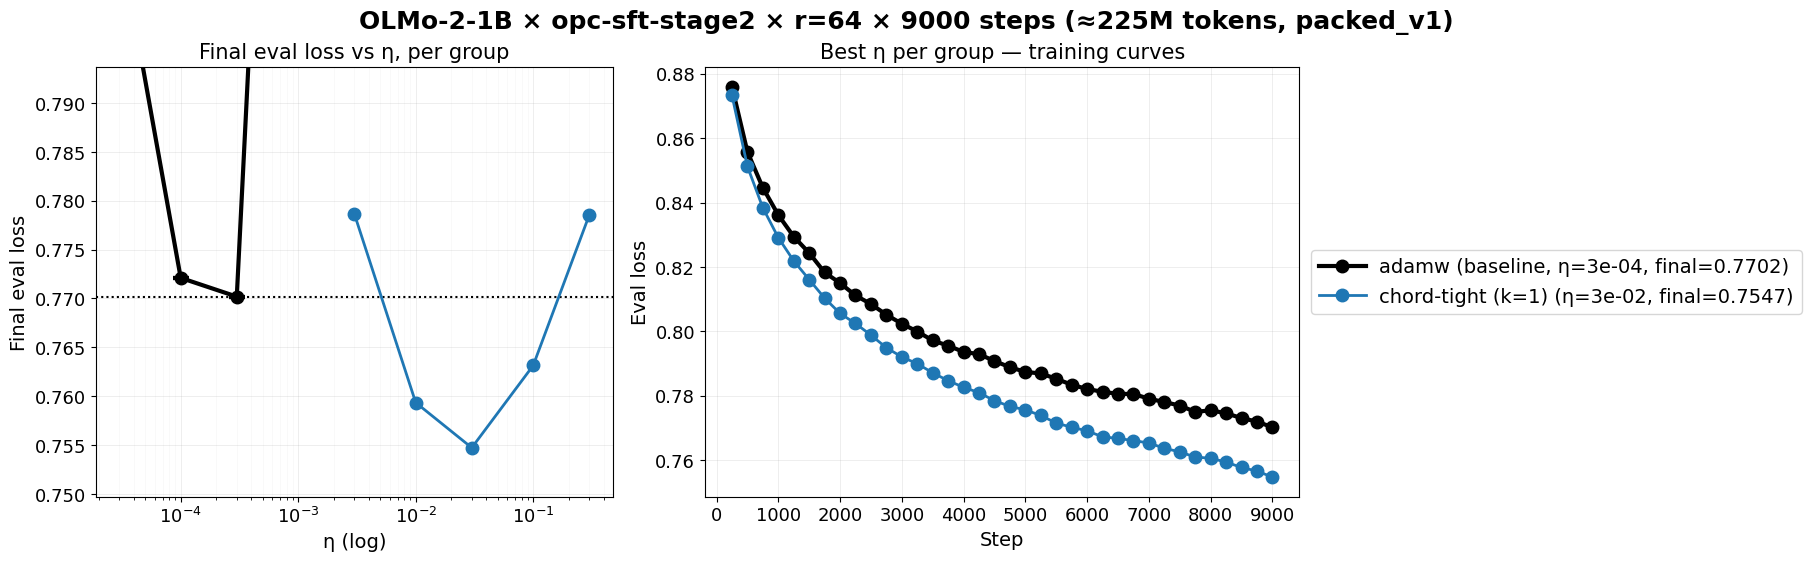

In [3]:
def group_key(cfg):
    return 'chord-tight (k=1)'  # only the candidate gets a group_key; ref runs are the AdamW overlay

color_map = {'chord-tight (k=1)': '#1f77b4'}
marker_map = {'chord-tight (k=1)': 'o'}

ref_runs  = [(c, e) for c, e in runs if c['optimizer'] == 'adamw']
cand_runs = [(c, e) for c, e in runs if c['optimizer'] != 'adamw']

standard_sweep_figure(
    cand_runs,
    group_key_fn=group_key,
    color_map=color_map,
    marker_map=marker_map,
    reference_runs=ref_runs,
    suptitle='OLMo-2-1B × opc-sft-stage2 × r=64 × 9000 steps (≈225M tokens, packed_v1)',
    figsize=(18, 5.5),
    x_tick_step=1000,
)
plt.show()